# Quantitative Regel-Adhärenz & Metriken-Evaluation für Leichte Sprache
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook dient der empirischen, quantitativen Analyse der **Regeleinhaltung** von Leichter Sprache nach den Richtlinien des *Netzwerks Leichte Sprache*, der *BITV 2.0* und des *Duden: Leichte Sprache*.

---
## 1. Systematische Übersicht: Alle 14 Regeln, Metriken & Technologien

| # | Regelbereich | Offizielle LS-Regel | Quantitative Metrik | Technologie & Parser | Zielrichtung (LS vs. AS) |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **S1** | **Syntax** | **Kurze Sätze** (max. 8–12 Wörter) | Mean Sentence Length (MSL) & Long Sentence Ratio (>12 Wörter) | `spacy` (`de_core_news_lg`): `doc.sents` | $\downarrow$ MSL $\le 8-10$, Long Sents $\approx 0$ |
| **S2** | **Syntax** | **Keine Nebensätze** (Nur Hauptsätze, Parataxe) | Subordination Ratio (Nebensätze pro Satz) | `spacy` Dep (`relcl`, `advcl`, `ccomp`) & POS (`SCONJ`) | $\downarrow$ Sinkt drastisch gegen $0.0$ |
| **S3** | **Syntax** | **SPO-Struktur** (Subjekt-Prädikat-Objekt) | Subject-Initial Sentence Ratio | `spacy` Dependency Parsing: `sb` am Satzanfang | $\uparrow$ Steigt in LS |
| **G1** | **Grammatik** | **Kein Passiv** (Nur Aktivformulierungen) | Passive Voice Ratio (Passivkonstruktionen pro Satz) | `spacy` Morph/Dep: `sb_pass` & *werden* + Partizip II | $\downarrow$ Sinkt gegen $0.0$ |
| **G2** | **Grammatik** | **Kein Genitiv** (Ersatz durch Dativ mit *von*) | Genitive Noun Ratio (Genitive pro Nomen/Pronomen) | `spacy` Morph: `Case=Gen` | $\downarrow$ Sinkt um $>85\%$ bis $100\%$ |
| **G3** | **Grammatik** | **Kein Konjunktiv** (Nur Indikativ/Tatsachen) | Subjunctive Mood Ratio (Konjunktiv pro finitem Verb) | `spacy` Morph: `Mood=Sub` | $\downarrow$ Nahezu $0.0$ |
| **G4** | **Grammatik** | **Verbalstil statt Nominalstil** | Nominalization Density & Verb-to-Noun Ratio | `regex` Suffixfilter (`-ung`, `-heit`, etc.) + POS | $\downarrow$ Nominalisierungen sinken; VNR $\uparrow$ |
| **G5** | **Grammatik** | **Wenig/keine Verneinungen** | Negation Density (*nicht*, *kein*, *weder*, etc.) | `regex` / Lemma-Matching | $\downarrow$ Sinkt in LS |
| **L1** | **Lexik** | **Kurze, einfache Wörter** | Polysyllable Ratio ($\ge 3$ Silben) & Mittlere Wortlänge | `pyphen` (de_DE Silbentrennung) & `textstat` | $\downarrow$ Sinkt signifikant |
| **L2** | **Lexik** | **Komposita trennen** (Bindestrich / Mediopunkt) | Compound Hyphenation Ratio | `regex`: Substantive mit `-` oder `·` | $\uparrow$ Steigt in LS stark an |
| **L3** | **Lexik** | **Keine Abkürzungen** (Wörter ausschreiben) | Abbreviation Density (*z. B.*, *bzw.*, Akronyme) | `regex` Pattern Matching | $\downarrow$ Sinkt gegen $0.0$ |
| **L4** | **Lexik** | **Zahlen als Ziffern** (*12* statt *zwölf*) | Digit Ratio (Ziffern vs. Zahlwörter) | `regex`: `\d+` vs. Zahlwort-Wörterbuch | $\uparrow$ Steigt gegen $1.0$ |
| **K1** | **Lesbarkeit**| **Standard-Lesbarkeitsformeln** | Wiener Sachtextformel (WSTF) & Flesch (DE) | `textstat` (lang='de') | WSTF sinkt (Ziel $\le 6$); Flesch $>70$ |
| **S1** | **Semantik** | **Sinn- & Fakten-Erhaltung** | Dense SBERT Semantic Similarity | `sentence-transformers` (Jina v2 8192) | Hohe Ähnlichkeit ($0.70 - 0.95$) |


In [1]:
# ==============================================================================
# 2. SETUP & IMPORTE
# ==============================================================================
import os
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Arbeitsverzeichnis setzen
while not (os.path.exists("data") and os.path.exists("scripts")) and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")
print("Arbeitsverzeichnis:", os.getcwd())

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.dpi"] = 150


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis


---
## 3. Korpus-Analyse: Wie streng halten sich die 12 Quellen an die Regeln?

Wir laden die Vorher-Nachher-Ergebnisse des 12-Quellen-Korpus (`data/analysis/rule_adherence_corpus.csv`).

In [2]:
corpus_file = "data/analysis/rule_adherence_corpus.csv"
df_corpus = pd.read_csv(corpus_file)
print(f"Geladene Artikelpaare: {len(df_corpus)} aus {df_corpus['source'].nunique()} Quellen.")

cols_overview = [
    "as_avg_sent_len", "ls_avg_sent_len", "red_red_sent_len_pct",
    "as_passive_ratio", "ls_passive_ratio", "red_red_passive_pct",
    "as_genitive_ratio", "ls_genitive_ratio", "red_red_genitive_pct",
    "as_wstf_score", "ls_wstf_score"
]

grouped_corpus = df_corpus.groupby("source")[cols_overview].mean().round(2)
grouped_corpus.columns = [
    "AS Satzlänge", "LS Satzlänge", "Satzkürzung (%)",
    "AS Passiv/Satz", "LS Passiv/Satz", "Passiv-Red. (%)",
    "AS Genitiv-Quote", "LS Genitiv-Quote", "Genitiv-Red. (%)",
    "AS WSTF", "LS WSTF"
]
display(grouped_corpus)


Geladene Artikelpaare: 882 aus 11 Quellen.


,AS Satzlänge,LS Satzlänge,Satzkürzung (%),AS Passiv/Satz,LS Passiv/Satz,Passiv-Red. (%),AS Genitiv-Quote,LS Genitiv-Quote,Genitiv-Red. (%),AS WSTF,LS WSTF
source,,,,,,,,,,,
apotheken,11.77,6.94,39.87,0.04,0.01,48.42,0.05,0.03,35.83,11.03,7.70
behindertenbeauftragter,15.52,8.97,39.73,0.05,0.05,8.60,0.10,0.03,73.62,11.96,8.96
brandeins,17.16,7.17,54.22,0.12,0.02,34.71,0.10,0.01,86.18,11.39,3.65
hamburg,13.63,6.92,47.17,0.07,0.01,60.39,0.08,0.01,90.77,11.63,6.17
hannover,11.96,6.67,41.35,0.05,0.00,57.80,0.06,0.00,86.50,11.18,6.66
koeln,12.38,7.83,34.90,0.09,0.01,77.00,0.10,0.01,90.65,11.66,6.10
main_taunus,13.19,7.35,38.62,0.04,0.00,31.27,0.05,0.01,51.82,11.00,6.26
mdr,12.13,7.70,35.08,0.07,0.06,-2.56,0.06,0.00,92.12,10.25,5.94
sozialpolitik,13.09,7.73,40.30,0.07,0.01,84.89,0.07,0.01,86.31,11.24,7.33


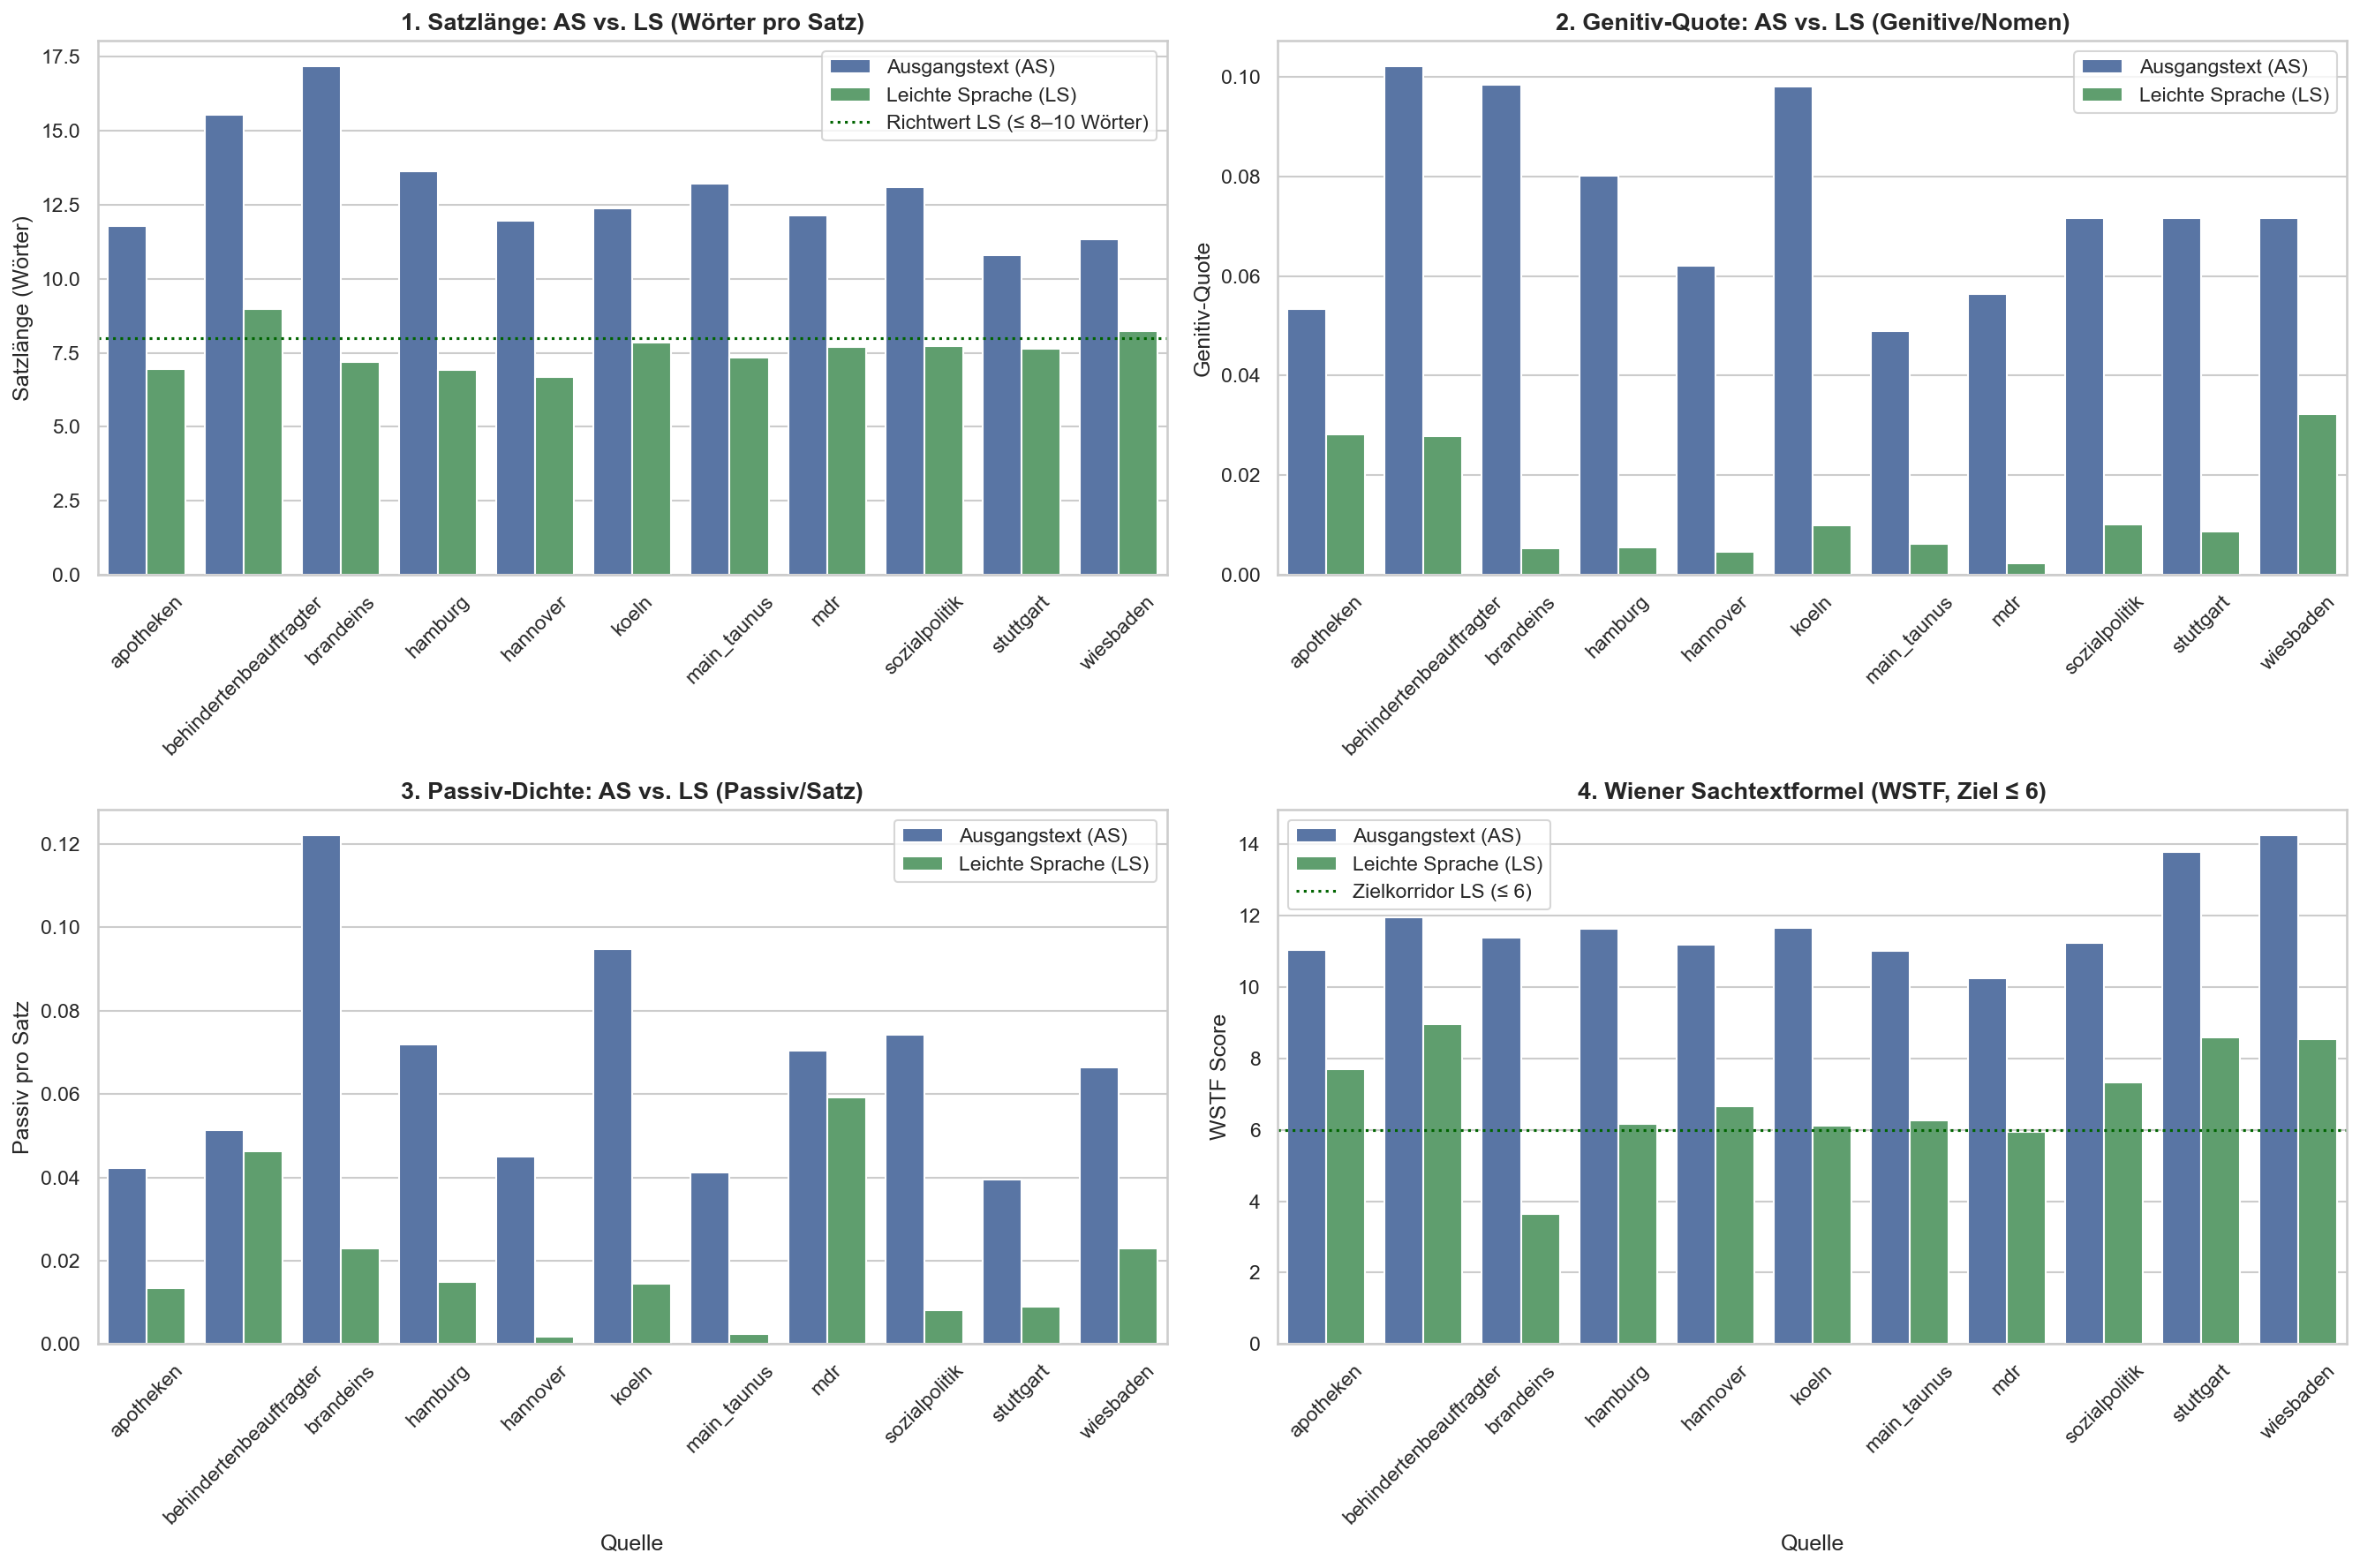

In [3]:
# ==============================================================================
# 3a. DIREKTER SIDE-BY-SIDE VERGLEICH PRO QUELLE (AS vs. LS in absoluten Werten)
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Satzlänge
df_sent = df_corpus.groupby('source')[['as_avg_sent_len', 'ls_avg_sent_len']].mean().reset_index()
df_sent_m = df_sent.melt(id_vars='source', var_name='Texttyp', value_name='Satzlänge (Wörter)')
df_sent_m['Texttyp'] = df_sent_m['Texttyp'].map({'as_avg_sent_len': 'Ausgangstext (AS)', 'ls_avg_sent_len': 'Leichte Sprache (LS)'})
sns.barplot(data=df_sent_m, x='source', y='Satzlänge (Wörter)', hue='Texttyp', ax=axes[0, 0], palette=['#4c72b0', '#55a868'])
axes[0, 0].set_title('1. Satzlänge: AS vs. LS (Wörter pro Satz)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].axhline(8.0, color='darkgreen', linestyle=':', label='Richtwert LS (≤ 8–10 Wörter)')
axes[0, 0].legend()

# 2. Genitiv-Quote
df_gen = df_corpus.groupby('source')[['as_genitive_ratio', 'ls_genitive_ratio']].mean().reset_index()
df_gen_m = df_gen.melt(id_vars='source', var_name='Texttyp', value_name='Genitiv-Quote')
df_gen_m['Texttyp'] = df_gen_m['Texttyp'].map({'as_genitive_ratio': 'Ausgangstext (AS)', 'ls_genitive_ratio': 'Leichte Sprache (LS)'})
sns.barplot(data=df_gen_m, x='source', y='Genitiv-Quote', hue='Texttyp', ax=axes[0, 1], palette=['#4c72b0', '#55a868'])
axes[0, 1].set_title('2. Genitiv-Quote: AS vs. LS (Genitive/Nomen)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend()

# 3. Passiv pro Satz
df_pass = df_corpus.groupby('source')[['as_passive_ratio', 'ls_passive_ratio']].mean().reset_index()
df_pass_m = df_pass.melt(id_vars='source', var_name='Texttyp', value_name='Passiv pro Satz')
df_pass_m['Texttyp'] = df_pass_m['Texttyp'].map({'as_passive_ratio': 'Ausgangstext (AS)', 'ls_passive_ratio': 'Leichte Sprache (LS)'})
sns.barplot(data=df_pass_m, x='source', y='Passiv pro Satz', hue='Texttyp', ax=axes[1, 0], palette=['#4c72b0', '#55a868'])
axes[1, 0].set_title('3. Passiv-Dichte: AS vs. LS (Passiv/Satz)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Quelle')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend()

# 4. Wiener Sachtextformel
df_wstf = df_corpus.groupby('source')[['as_wstf_score', 'ls_wstf_score']].mean().reset_index()
df_wstf_m = df_wstf.melt(id_vars='source', var_name='Texttyp', value_name='WSTF Score')
df_wstf_m['Texttyp'] = df_wstf_m['Texttyp'].map({'as_wstf_score': 'Ausgangstext (AS)', 'ls_wstf_score': 'Leichte Sprache (LS)'})
sns.barplot(data=df_wstf_m, x='source', y='WSTF Score', hue='Texttyp', ax=axes[1, 1], palette=['#4c72b0', '#55a868'])
axes[1, 1].set_title('4. Wiener Sachtextformel (WSTF, Ziel ≤ 6)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Quelle')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].axhline(6.0, color='darkgreen', linestyle=':', label='Zielkorridor LS (≤ 6)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()


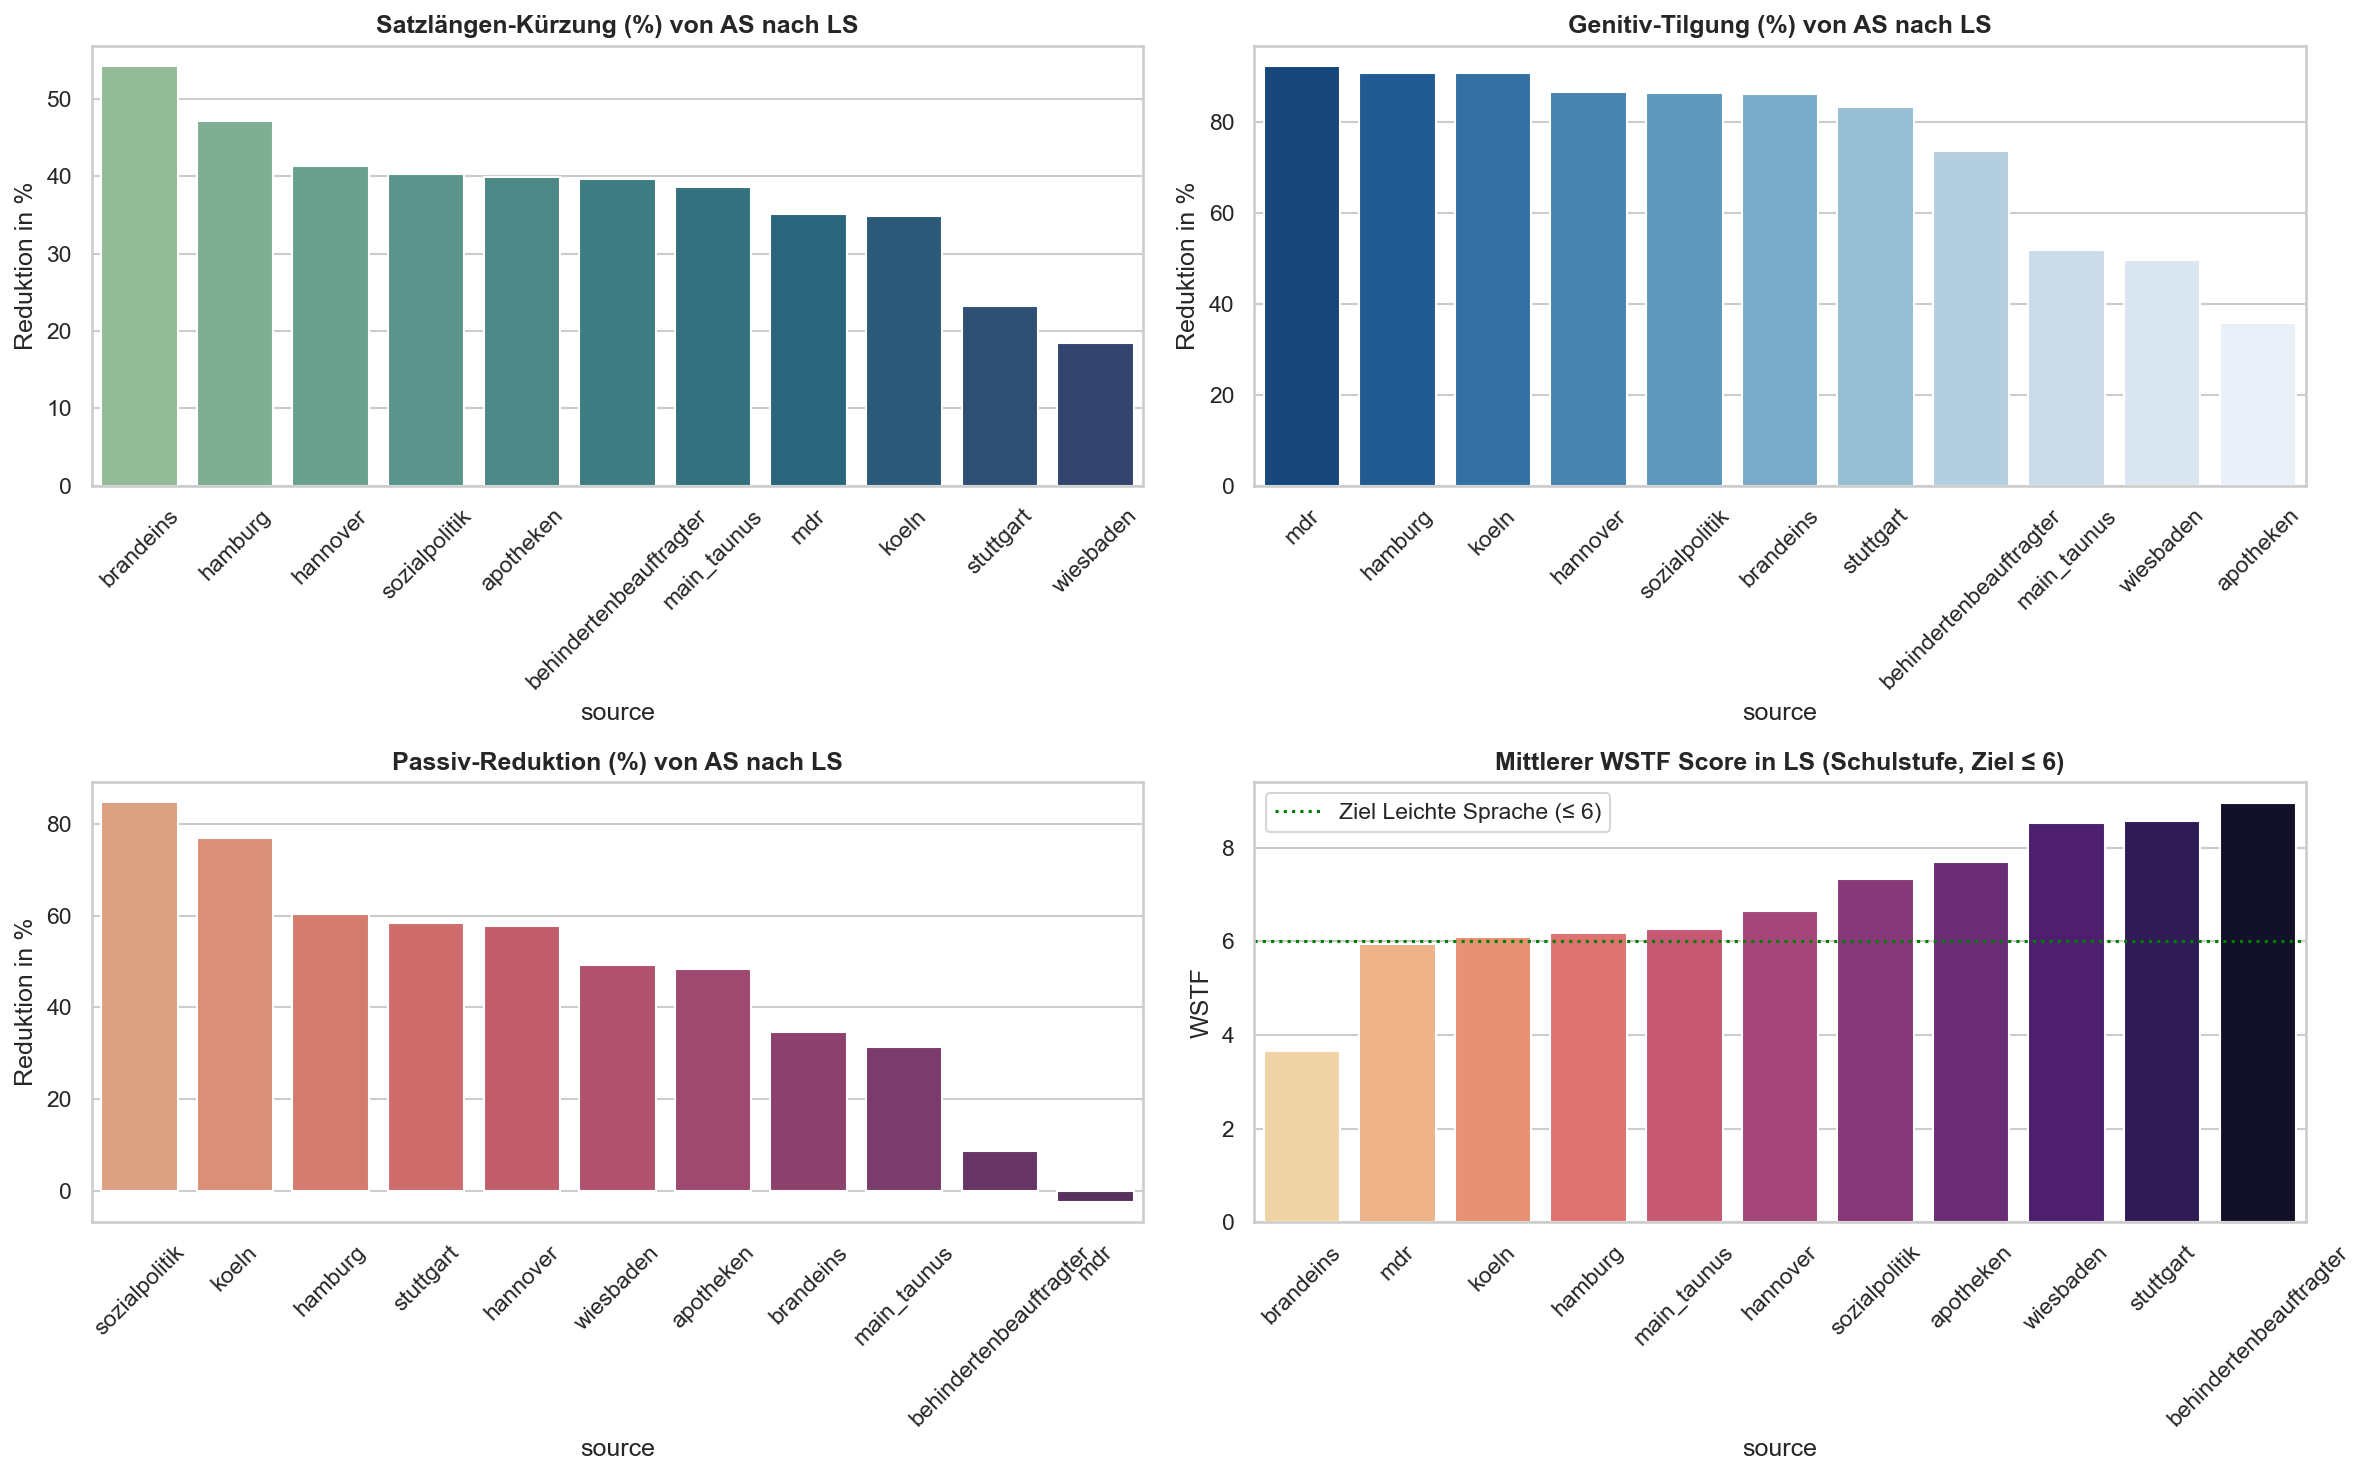

In [4]:
# ==============================================================================
# 3b. PROZENTUALE REDUKTIONSRATEN PRO QUELLE
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
df_plot = df_corpus.groupby("source")[["red_red_sent_len_pct", "red_red_genitive_pct", "red_red_passive_pct", "ls_wstf_score"]].mean().reset_index()

# 1. Satzlängen-Kürzung
sns.barplot(data=df_plot.sort_values("red_red_sent_len_pct", ascending=False), x="source", y="red_red_sent_len_pct", ax=axes[0, 0], hue="source", legend=False, palette="crest")
axes[0, 0].set_title("Satzlängen-Kürzung (%) von AS nach LS", fontsize=12, fontweight="bold")
axes[0, 0].set_ylabel("Reduktion in %")
axes[0, 0].tick_params(axis="x", rotation=45)

# 2. Genitiv-Tilgung
sns.barplot(data=df_plot.sort_values("red_red_genitive_pct", ascending=False), x="source", y="red_red_genitive_pct", ax=axes[0, 1], hue="source", legend=False, palette="Blues_r")
axes[0, 1].set_title("Genitiv-Tilgung (%) von AS nach LS", fontsize=12, fontweight="bold")
axes[0, 1].set_ylabel("Reduktion in %")
axes[0, 1].tick_params(axis="x", rotation=45)

# 3. Passiv-Reduktion
sns.barplot(data=df_plot.sort_values("red_red_passive_pct", ascending=False), x="source", y="red_red_passive_pct", ax=axes[1, 0], hue="source", legend=False, palette="flare")
axes[1, 0].set_title("Passiv-Reduktion (%) von AS nach LS", fontsize=12, fontweight="bold")
axes[1, 0].set_ylabel("Reduktion in %")
axes[1, 0].tick_params(axis="x", rotation=45)

# 4. Wiener Sachtextformel in LS
sns.barplot(data=df_plot.sort_values("ls_wstf_score", ascending=True), x="source", y="ls_wstf_score", ax=axes[1, 1], hue="source", legend=False, palette="magma_r")
axes[1, 1].set_title("Mittlerer WSTF Score in LS (Schulstufe, Ziel ≤ 6)", fontsize=12, fontweight="bold")
axes[1, 1].axhline(6.0, color="green", linestyle=":", label="Ziel Leichte Sprache (≤ 6)")
axes[1, 1].set_ylabel("WSTF")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


---
## 4. Modell-Evaluation: Umfassendes Regel-Dashboard über alle Dimensionen

Hier vergleichen wir die 500-Token Modellgenerierungen über alle 14 gemessenen Regel-Metriken mit dem Ausgangstext (AS) und der menschlichen Gold-Referenz der Lebenshilfe.

In [5]:
ladder_file = "data/analysis/rule_adherence_ladder_sft.csv"

if os.path.exists(ladder_file):
    df_ladder = pd.read_csv(ladder_file)
    
    metrics_map = {
        'avg_sent_len': '1. Satzlänge (Wörter)',
        'long_sent_ratio': '2. Lange Sätze (>12 W) %',
        'subord_ratio': '3. Nebensätze / Satz',
        'passive_ratio': '4. Passiv / Satz',
        'genitive_ratio': '5. Genitiv-Quote (pro Nomen)',
        'subjunctive_ratio': '6. Konjunktiv-Quote (pro Verb)',
        'nominal_ratio': '7. Nominalstil-Quote',
        'verb_to_noun_ratio': '8. Verb-zu-Nomen-Verhältnis',
        'polysyllable_ratio': '9. Polysilben-Quote (≥3 Silben)',
        'hyphen_compound_ratio': '10. Komposita-Trennung %',
        'abbr_ratio': '11. Abkürzungs-Quote',
        'digit_ratio': '12. Ziffern-Quote %',
        'wstf_score': '13. Wiener Sachtextformel',
        'flesch_score': '14. Flesch Reading Ease (DE)'
    }

    rows = []
    for k, name in metrics_map.items():
        as_val = df_ladder[f'as_{k}'].mean()
        gen_val = df_ladder[f'gen_{k}'].mean()
        ref_val = df_ladder[f'ref_{k}'].mean()
        
        red_sft = ((as_val - gen_val) / as_val * 100) if as_val > 0 else 0
        rows.append({
            'Regel-Metrik': name,
            'AS Original': round(as_val, 3),
            'SFT Modell (500)': round(gen_val, 3),
            'Lebenshilfe Gold': round(ref_val, 3),
            'SFT Reduktion (%)': f'{red_sft:+.1f}%' if 'Flesch' not in name and 'Ziffer' not in name and 'Verb-zu-Nomen' not in name and 'Trennung' not in name else f'{(gen_val - as_val):+.2f} Pkt'
        })

    df_full_metrics = pd.DataFrame(rows)
    display(df_full_metrics)


,Regel-Metrik,AS Original,SFT Modell (500),Lebenshilfe Gold,SFT Reduktion (%)
0,1. Satzlänge (Wörter),12.497,7.712,6.792,+38.3%
1,2. Lange Sätze (>12 W) %,0.424,0.112,0.033,+73.6%
2,3. Nebensätze / Satz,0.108,0.069,0.018,+36.2%
3,4. Passiv / Satz,0.093,0.023,0.020,+75.4%
4,5. Genitiv-Quote (pro Nomen),0.092,0.021,0.010,+77.4%
5,6. Konjunktiv-Quote (pro Verb),0.005,0.001,0.002,+74.1%
6,7. Nominalstil-Quote,0.050,0.036,0.034,+28.2%
7,8. Verb-zu-Nomen-Verhältnis,0.406,0.614,0.567,+0.21 Pkt
8,9. Polysilben-Quote (≥3 Silben),0.330,0.231,0.234,+30.0%
9,10. Komposita-Trennung %,0.029,0.169,0.117,+0.14 Pkt


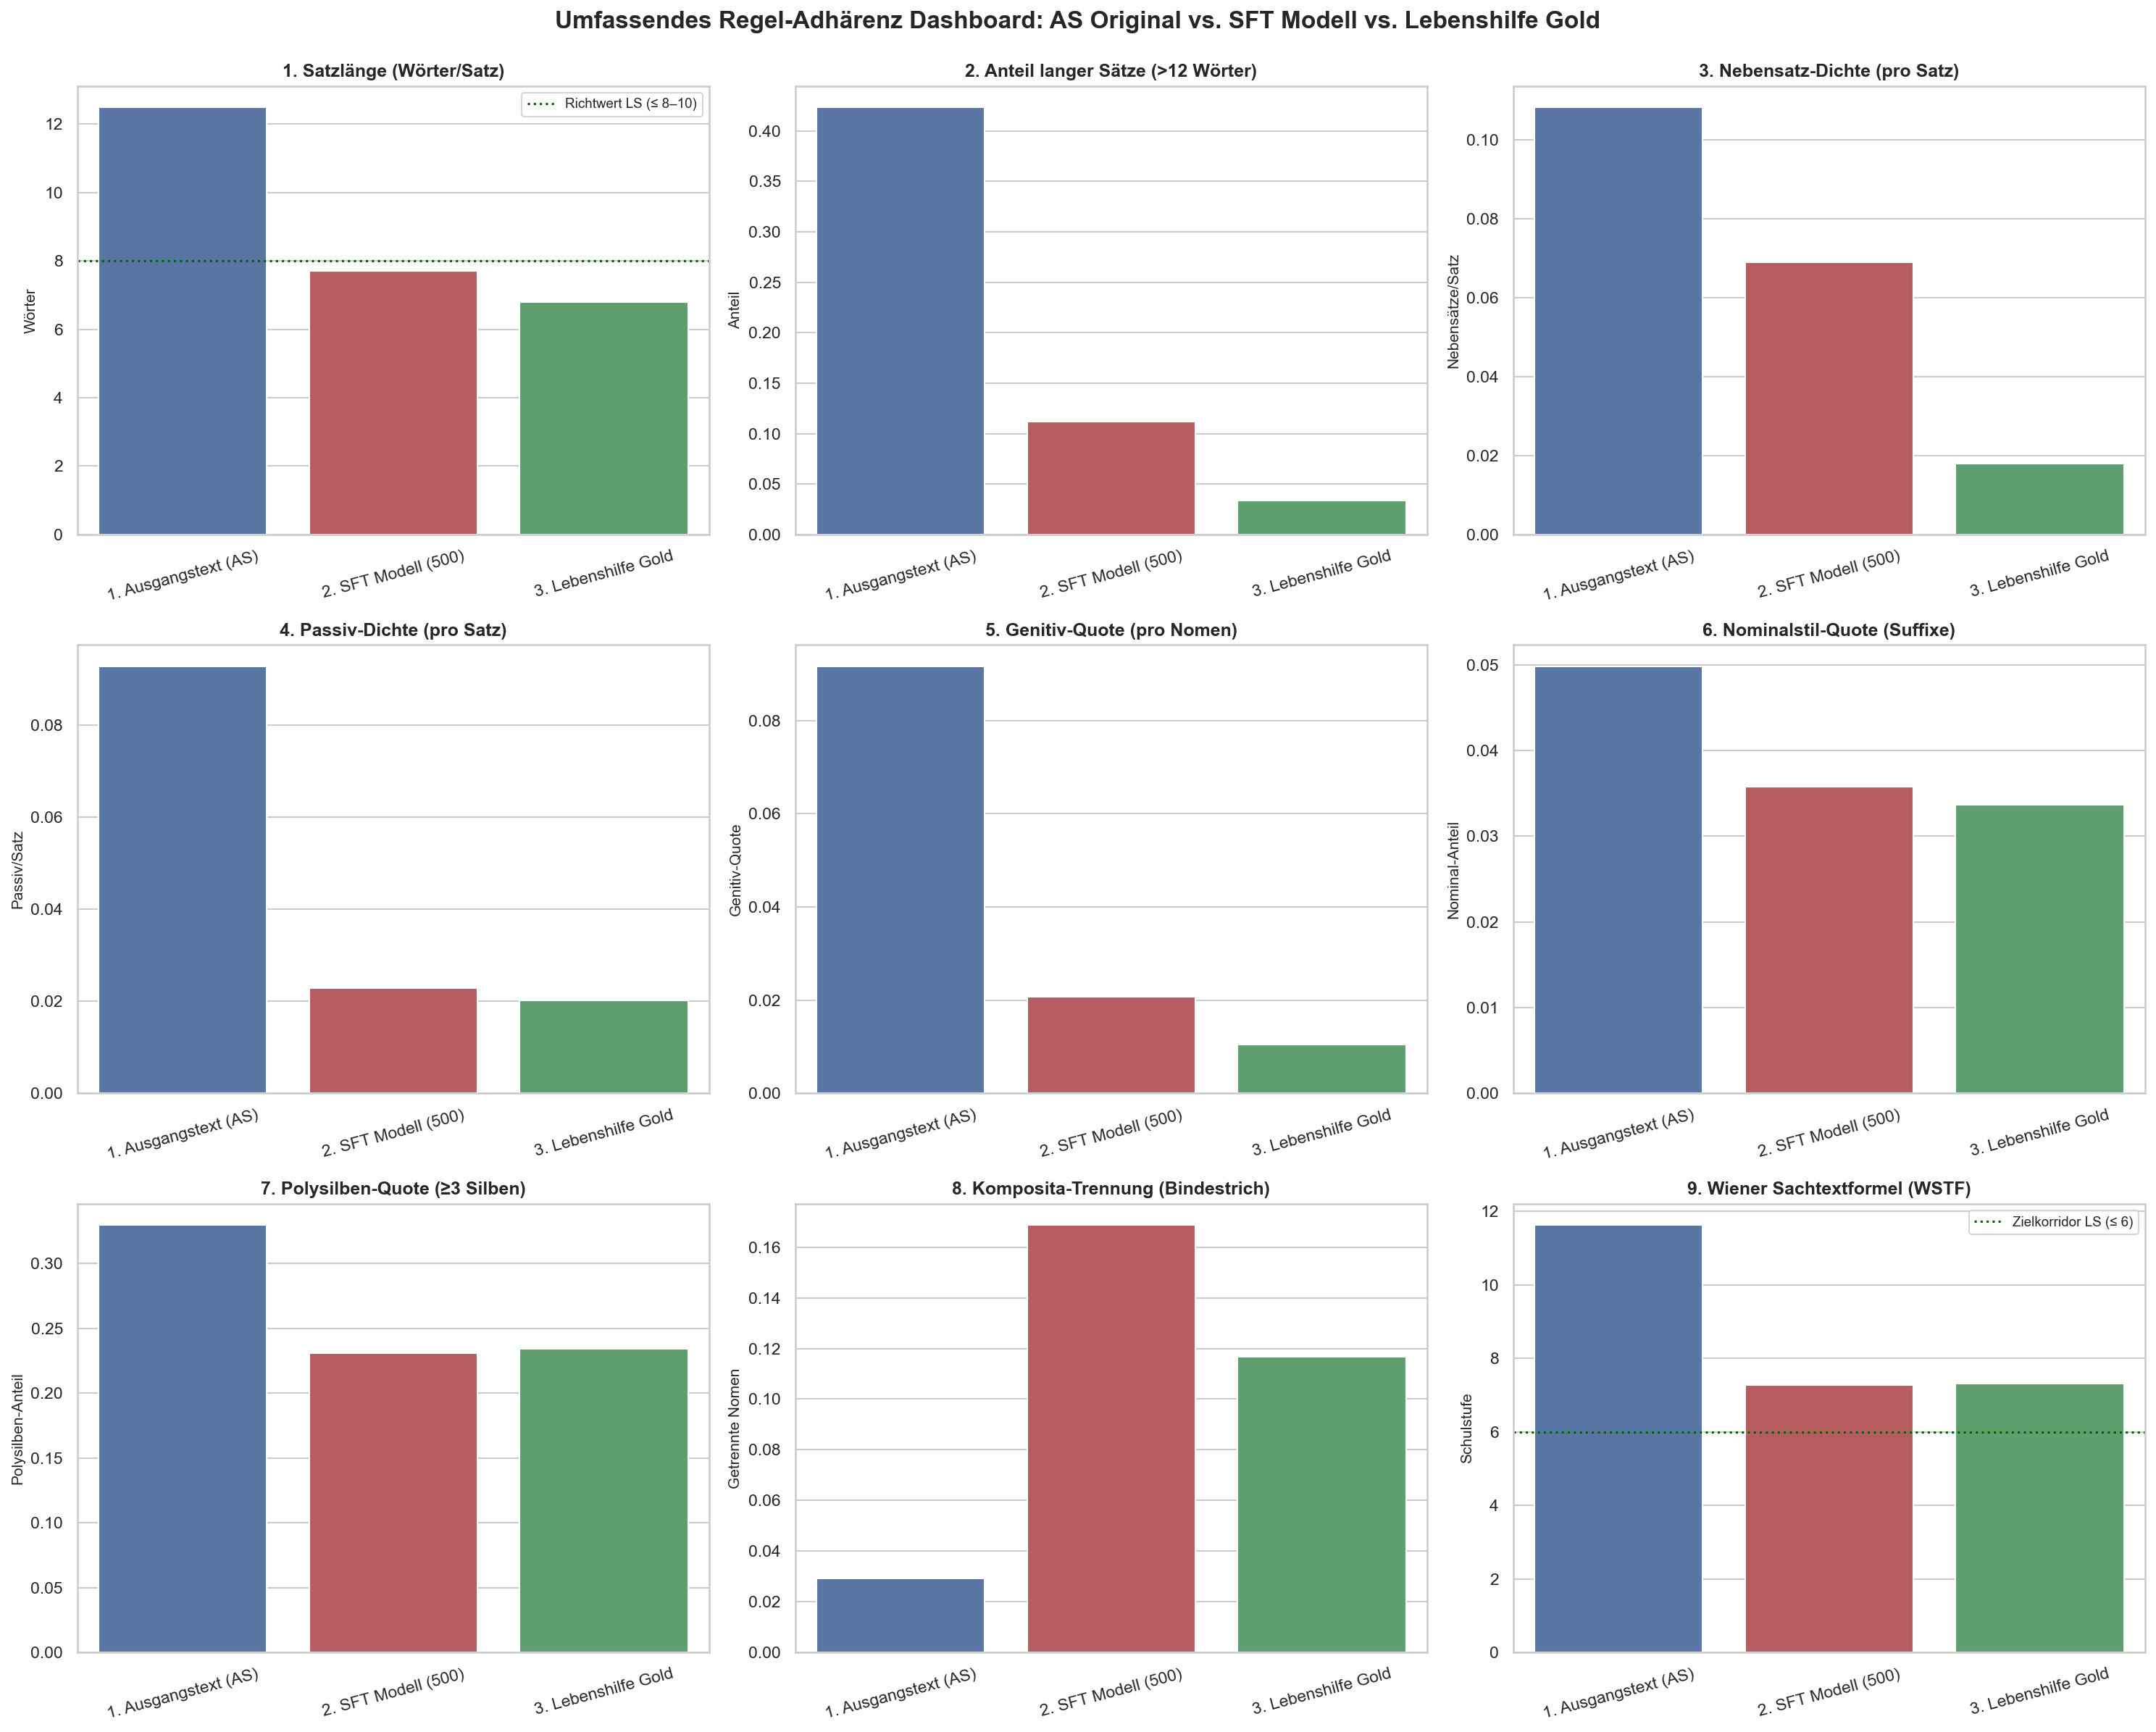

In [6]:
# ==============================================================================
# 4b. UMFASSENDES 9-PANEL DASHBOARD (Syntax, Grammatik, Lexik, Lesbarkeit)
# ==============================================================================
if os.path.exists(ladder_file):
    metrics_to_plot = [
        ("avg_sent_len", "1. Satzlänge (Wörter/Satz)", "Wörter", 8.0, "Richtwert LS (≤ 8–10)"),
        ("long_sent_ratio", "2. Anteil langer Sätze (>12 Wörter)", "Anteil", None, None),
        ("subord_ratio", "3. Nebensatz-Dichte (pro Satz)", "Nebensätze/Satz", None, None),
        ("passive_ratio", "4. Passiv-Dichte (pro Satz)", "Passiv/Satz", None, None),
        ("genitive_ratio", "5. Genitiv-Quote (pro Nomen)", "Genitiv-Quote", None, None),
        ("nominal_ratio", "6. Nominalstil-Quote (Suffixe)", "Nominal-Anteil", None, None),
        ("polysyllable_ratio", "7. Polysilben-Quote (≥3 Silben)", "Polysilben-Anteil", None, None),
        ("hyphen_compound_ratio", "8. Komposita-Trennung (Bindestrich)", "Getrennte Nomen", None, None),
        ("wstf_score", "9. Wiener Sachtextformel (WSTF)", "Schulstufe", 6.0, "Zielkorridor LS (≤ 6)")
    ]

    fig, axes = plt.subplots(3, 3, figsize=(20, 16))
    axes = axes.flatten()

    for idx, (key, title, ylabel, threshold, thresh_label) in enumerate(metrics_to_plot):
        as_val = df_ladder[f"as_{key}"].mean()
        gen_val = df_ladder[f"gen_{key}"].mean()
        ref_val = df_ladder[f"ref_{key}"].mean()

        data_rows = [
            {"Stufe": "1. Ausgangstext (AS)", "Wert": as_val},
            {"Stufe": "2. SFT Modell (500)", "Wert": gen_val},
            {"Stufe": "3. Lebenshilfe Gold", "Wert": ref_val}
        ]
        df_p = pd.DataFrame(data_rows)

        ax = axes[idx]
        sns.barplot(data=df_p, x="Stufe", y="Wert", ax=ax, hue="Stufe", legend=False, palette=["#4c72b0", "#c44e52", "#55a868"])
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel(ylabel, fontsize=10)
        ax.tick_params(axis='x', rotation=15)

        if threshold is not None:
            ax.axhline(threshold, color="darkgreen", linestyle=":", label=thresh_label)
            ax.legend(fontsize=9)

    plt.suptitle("Umfassendes Regel-Adhärenz Dashboard: AS Original vs. SFT Modell vs. Lebenshilfe Gold", fontsize=16, fontweight="bold", y=0.995)
    plt.tight_layout()
    plt.show()


---
## 5. Interaktiver Text-Auditor: Live-Analyse für beliebige Texte

Nutze diese Funktion, um Ausgangssätze (AS) und vereinfachte Sätze (LS / Modell) live zu analysieren und direkt die Regel-Adhärenz zu prüfen.

In [7]:
from scripts.evaluation.measure_rule_adherence import LeichteSpracheRuleAuditor

auditor = LeichteSpracheRuleAuditor()

def live_audit(as_text: str, ls_text: str):
    as_doc = auditor.nlp(as_text)
    ls_doc = auditor.nlp(ls_text)
    
    as_m = auditor.analyze_doc(as_doc)
    ls_m = auditor.analyze_doc(ls_doc)
    red_m = auditor.calculate_reduction_delta(as_m, ls_m)
    
    print("=================== LIVE REGEL-AUDIT ===================")
    print(f"[AS Original]: {as_text[:120]}...")
    print(f"[LS Zieltext]: {ls_text[:120]}...")
    print("--------------------------------------------------------")
    print(f"Satzlänge:        {as_m['avg_sent_len']:.1f} Wörter -> {ls_m['avg_sent_len']:.1f} Wörter ({red_m['red_sent_len_pct']:+.1f}% Reduktion)")
    print(f"Passiv/Satz:      {as_m['passive_ratio']:.2f} -> {ls_m['passive_ratio']:.2f} ({red_m['red_passive_pct']:+.1f}% Reduktion)")
    print(f"Genitiv-Quote:    {as_m['genitive_ratio']:.2f} -> {ls_m['genitive_ratio']:.2f} ({red_m['red_genitive_pct']:+.1f}% Reduktion)")
    print(f"Nebensatz-Dichte: {as_m['subord_ratio']:.2f} -> {ls_m['subord_ratio']:.2f} ({red_m['red_subord_pct']:+.1f}% Reduktion)")
    print(f"Nominalstil:      {as_m['nominal_ratio']:.2f} -> {ls_m['nominal_ratio']:.2f} ({red_m['red_nominal_pct']:+.1f}% Reduktion)")
    print(f"WSTF (Lesbarkeit): {as_m['wstf_score']:.1f} -> {ls_m['wstf_score']:.1f}")
    print("========================================================")

# Test-Beispiel:
as_sample = "Die Genehmigung des Antrags wird durch die zuständige Behörde nach sorgfältiger Prüfung der Unterlagen erteilt."
ls_sample = "Das Amt prüft die Papiere. Danach erlaubt das Amt den Antrag."
live_audit(as_sample, ls_sample)


Loading SpaCy model: de_core_news_lg...
=================== LIVE REGEL-AUDIT ===================
[AS Original]: Die Genehmigung des Antrags wird durch die zuständige Behörde nach sorgfältiger Prüfung der Unterlagen erteilt....
[LS Zieltext]: Das Amt prüft die Papiere. Danach erlaubt das Amt den Antrag....
--------------------------------------------------------
Satzlänge:        15.0 Wörter -> 5.5 Wörter (+63.3% Reduktion)
Passiv/Satz:      1.00 -> 0.00 (+100.0% Reduktion)
Genitiv-Quote:    0.40 -> 0.00 (+100.0% Reduktion)
Nebensatz-Dichte: 0.00 -> 0.00 (+0.0% Reduktion)
Nominalstil:      0.13 -> 0.00 (+100.0% Reduktion)
WSTF (Lesbarkeit): 13.5 -> 2.1
